# RQ3: Runtime Requirements

**Research Question**: What are the runtime requirements of the generalization approach?

This notebook analyzes the runtime requirements for Teralizer tool execution across different configurations:
- **Total Runtime**: Teralizer execution time per project
- **Pipeline Stages**: Runtime breakdown by processing stage and variant
- **Stage/Step Breakdown**: Detailed runtime analysis by processing steps within each stage
- **Efficiency Comparison**: Pareto front analysis comparing EvoSuite and Teralizer
- **EvoSuite Analysis**: Runtime breakdown by phase and search budget

In [1]:
from teralizer.config import db_config
from teralizer.rq3_runtime_requirements import (
    get_teralizer_total_runtimes,
    get_teralizer_runtime_by_stage,
    get_evosuite_vs_teralizer_efficiency,
    get_evosuite_runtime_analysis,
    get_stage_step_runtime_breakdown,
    compute_teralizer_runtime_statistics,
    compute_stage_runtime_breakdown,
    compute_pareto_efficiency_analysis,
    compute_evosuite_phase_statistics,
    compute_stage_step_runtime_statistics,
    generate_teralizer_runtimes_table,
    generate_runtime_breakdown_csv,
    generate_pareto_efficiency_csv,
    generate_evosuite_runtime_csv,
    generate_teralizer_runtimes_csv,
    generate_pareto_points_table,
    generate_stage_step_breakdown_csv,
    generate_stage_step_statistics_csv,
)
from teralizer.exports import (
    save_latex_table,
    save_csv_data,
    save_figure,
    get_table_group_order,
    get_project_within_type_order,
)
from teralizer.plotting import setup_paper_style
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

# Database connection
conn = db_config.get_dev_engine()

# Configure paper style
setup_paper_style()

## Total Teralizer Runtime per Project

Establishes the overall runtime baseline by showing total execution time required for each project.

In [2]:
# Get and process total runtime data
df_total_runtimes = get_teralizer_total_runtimes(conn)
df_total_runtimes_processed = compute_teralizer_runtime_statistics(df_total_runtimes)

# Generate and save LaTeX table
latex_table = generate_teralizer_runtimes_table(df_total_runtimes_processed)
save_latex_table(latex_table, "tab-teralizer-runtimes")

# Display the table
print(latex_table)

# Display data for reference
display_df = df_total_runtimes_processed[["project_name", "runtime"]].copy()
display_df["runtime_formatted"] = display_df["runtime"].apply(
    lambda x: f"{int(x // 3600)}h {int((x % 3600) // 60):02d}min {int(x % 60):02d}s"
)
display_df = display_df.rename(
    columns={"project_name": "Project", "runtime_formatted": "Runtime"}
)
display(display_df[["Project", "Runtime"]])

# Export CSV data
csv_data = generate_teralizer_runtimes_csv(df_total_runtimes_processed)
save_csv_data(csv_data, "teralizer-total-runtimes")

Saved LaTeX table to /app/analysis/output/verify/tables/tab-teralizer-runtimes.tex
\begin{table}[H]
  \caption{Total runtimes of Teralizer for all evaluated projects.}
  \label{tab:teralizer-runtimes}
  \begin{tabular}{lr}
    \toprule
    Project & Runtime \\
    \midrule
    \DatasetEqBenchA{} & 24h 46min 27s \\
    \DatasetEqBenchB{} & 28h 16min 32s \\
    \DatasetEqBenchC{} & 30h 53min 22s \\
    \midrule
    \DatasetCommonsA{} & 8h 13min 55s \\
    \DatasetCommonsB{} & 9h 46min 48s \\
    \DatasetCommonsC{} & 9h 04min 32s \\
    \midrule
    \DatasetCommonsDev{} & 3h 23min 22s \\
    \bottomrule
  \end{tabular}
\end{table}


,Project,Runtime
0,eqbench-es-default-1s,24h 46min 27s
5,eqbench-es-default-10s,28h 16min 32s
4,eqbench-es-default-60s,30h 53min 22s
3,commons-utils-es-default-1s,8h 13min 55s
6,commons-utils-es-default-10s,9h 46min 48s
2,commons-utils-es-default-60s,9h 04min 32s
1,commons-utils,3h 23min 22s


PosixPath('/app/analysis/output/verify/data/teralizer-total-runtimes.csv')

## Runtime Breakdown by Pipeline Stage

Detailed analysis of runtime distribution across different pipeline stages and generalization variants.

In [3]:
from teralizer.plotting import get_variant_color

# Get and process stage runtime data
df_stage_runtimes = get_teralizer_runtime_by_stage(conn)
df_stage_processed = compute_stage_runtime_breakdown(df_stage_runtimes)

# Get unique variants across all data, ordered by variant_order
variant_order_map = (
    df_stage_processed.drop_duplicates("variant")
    .set_index("variant")["variant_order"]
    .to_dict()
)
all_variants = sorted(
    df_stage_processed["variant"].unique(),
    key=lambda v: variant_order_map.get(v, float("inf")),
)
non_shared_variants = [v for v in all_variants if v != "SHARED"]

# Calculate total runtime per base project for sorting
base_project_totals = (
    df_stage_processed.groupby("base_project_name")["total_runtime"]
    .sum()
    .sort_values(ascending=False)
)
top_base_projects = base_project_totals.head(10).index.tolist()

# Filter for top base projects
top_projects_data = df_stage_processed[
    df_stage_processed["base_project_name"].isin(top_base_projects)
].copy()


color_map = {variant: get_variant_color(variant) for variant in all_variants}

# Define which variants apply to which stage groups, ordered by variant_order
ordered_groups = [
    "Stage 1 + 2",
    "Stage 3",
    "Stage 4",
    "Stage 5",
]

stage_group_variants = {
    "Stage 1 + 2": ["SHARED"],
    "Stage 3": ["SHARED"],
    "Stage 4": sorted(
        non_shared_variants, key=lambda v: variant_order_map.get(v, float("inf"))
    ),
    "Stage 5": sorted(
        non_shared_variants, key=lambda v: variant_order_map.get(v, float("inf"))
    ),
}

# Get unique project IDs for plotting, sorted by table order
project_within_type_order = get_project_within_type_order()
project_id_to_name = (
    top_projects_data.drop_duplicates("project_id")
    .set_index("project_id")["project_name"]
    .to_dict()
)
unique_project_ids = list(top_projects_data["project_id"].unique())

# Sort by table order
unique_project_ids = sorted(
    unique_project_ids,
    key=lambda pid: (
        get_table_group_order(project_id_to_name[pid], "INITIAL"),
        project_within_type_order.get(project_id_to_name[pid], 99),
    ),
)

print(
    f"Processing {len(unique_project_ids)} projects with {len(all_variants)} variants"
)
print(f"Stage groups: {ordered_groups}")
print(f"All variants: {all_variants}")

Processing 7 projects with 8 variants
Stage groups: ['Stage 1 + 2', 'Stage 3', 'Stage 4', 'Stage 5']
All variants: ['SHARED', 'BASELINE', 'NAIVE_10_TRIES', 'NAIVE_50_TRIES', 'NAIVE_200_TRIES', 'IMPROVED_10_TRIES', 'IMPROVED_50_TRIES', 'IMPROVED_200_TRIES']


In [4]:
# Define parameters for bar positioning
bar_width = 0.3
bar_spacing = 0.05
group_spacing = 0.3

# Count the number of bars in each group
bars_per_group = {
    group: len(variants) for group, variants in stage_group_variants.items()
}

# Calculate the total width of each group
group_widths = {
    group: (count * bar_width) + ((count - 1) * bar_spacing) if count > 0 else 0
    for group, count in bars_per_group.items()
}

# Calculate the center position of each group
group_centers = {}
current_position = 0
for group in ordered_groups:
    width = group_widths[group]
    group_centers[group] = current_position + width / 2
    current_position += width + group_spacing

# Calculate the position of each bar within its group
bar_positions = {}
for group in ordered_groups:
    variants = stage_group_variants[group]
    num_bars = len(variants)
    if num_bars == 0:
        continue
    group_center = group_centers[group]
    group_width = group_widths[group]
    start_pos = group_center - group_width / 2
    for i, variant in enumerate(variants):
        bar_positions[(group, variant)] = (
            start_pos + i * (bar_width + bar_spacing) + bar_width / 2
        )

# Create pivot tables for all projects
all_pivot_tables = {}
for project_id in unique_project_ids:
    project_data = top_projects_data[top_projects_data["project_id"] == project_id]
    pivot_data = pd.pivot_table(
        project_data,
        index="stage_group",
        columns="variant",
        values="total_runtime",
        aggfunc="sum",
        fill_value=0,
        observed=False,
    )
    all_pivot_tables[project_id] = pivot_data

# Define scaling groups
scaling_groups = {
    "eqbench-es": [
        "eqbench-es-default-1s",
        "eqbench-es-default-10s",
        "eqbench-es-default-60s",
    ],
    "commons-utils-es": [
        "commons-utils-es-default-1s",
        "commons-utils-es-default-10s",
        "commons-utils-es-default-60s",
    ],
    "commons-utils-dev": ["commons-utils"],
}

# Calculate max value for each scaling group
project_max_values = {}
for group_name, project_names in scaling_groups.items():
    max_value = 0
    for project_id in unique_project_ids:
        project_data = top_projects_data[top_projects_data["project_id"] == project_id]
        if project_data.empty:
            continue
        project_name = project_data["project_name"].iloc[0]
        if project_name in project_names:
            pivot_data = all_pivot_tables[project_id]
            if not pivot_data.empty:
                project_max = pivot_data.max().max()
                max_value = max(max_value, project_max)

    # Assign the max to all projects in this group
    for project_name in project_names:
        project_max_values[project_name] = max_value * 1.4


# Helper function to format runtime values
def format_runtime(seconds):
    if seconds < 10:
        return f"{seconds:.1f}"
    elif seconds < 100:
        return f"{seconds:.0f}"
    elif seconds < 1000:
        return f"{seconds:.0f}"
    else:
        return f"{seconds / 1000:.1f}k"


# Prepare multi-line x-tick labels
xtick_labels = [
    "Stage 1 + 2"
    if g == "Stage 1 + 2"
    else "Stage 3"
    if g == "Stage 3"
    else "Stage 4"
    if g == "Stage 4"
    else "Stage 5"
    if g == "Stage 5"
    else g
    for g in ordered_groups
]

print(
    f"Bar positioning setup complete. Total x-axis width: {current_position - group_spacing + 0.4}"
)

Bar positioning setup complete. Total x-axis width: 6.700000000000001


Saved figure to /app/analysis/output/verify/figures/fig_teralizer_runtimes.pdf


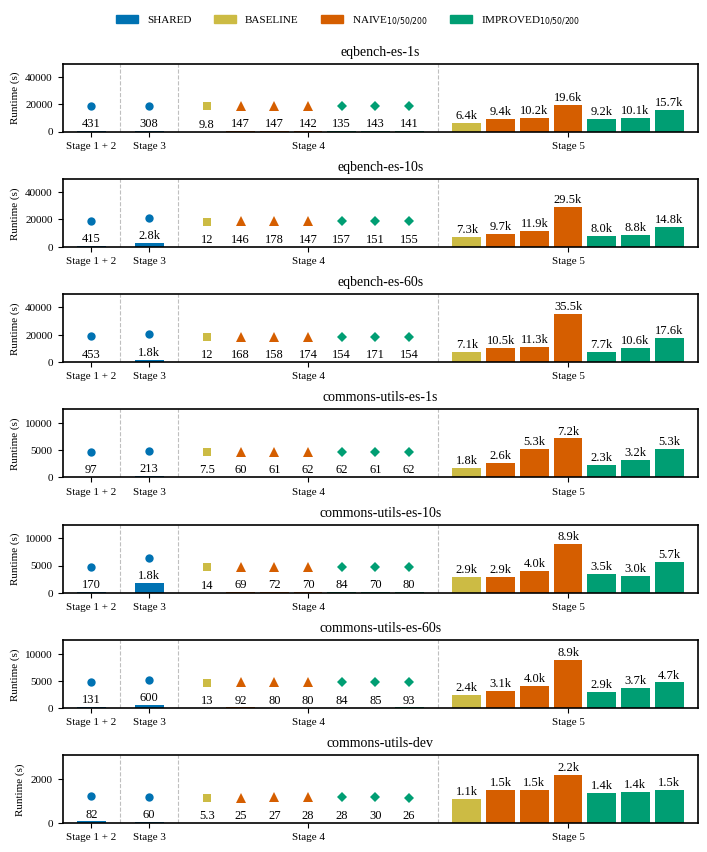

PosixPath('/app/analysis/output/verify/data/runtime-breakdown-data.csv')

In [5]:
# Plot runtime by stage group for each project
from teralizer.plotting import (
    get_font_size,
    FIGURE_CONFIG,
)
from teralizer.exports import standardize_project_name

# Calculate separator positions (centered between groups)
separator_positions = []
for i in range(len(ordered_groups) - 1):
    group = ordered_groups[i]
    separator_x = group_centers[group] + group_widths[group] / 2 + group_spacing / 2
    separator_positions.append(separator_x)

# Define marker shapes for each variant
marker_map = {
    "SHARED": "o",  # circle
    "BASELINE": "s",  # square
    "NAIVE_10_TRIES": "^",  # triangle up
    "NAIVE_50_TRIES": "^",  # triangle up
    "NAIVE_200_TRIES": "^",  # triangle up
    "IMPROVED_10_TRIES": "D",  # diamond
    "IMPROVED_50_TRIES": "D",  # diamond
    "IMPROVED_200_TRIES": "D",  # diamond
}

# Define marker sizes for each variant (adjust to balance visual weight)
marker_size_map = {
    "SHARED": 6,  # circle
    "BASELINE": 6,  # square
    "NAIVE_10_TRIES": 6.5,  # triangle
    "NAIVE_50_TRIES": 6.5,  # triangle
    "NAIVE_200_TRIES": 6.5,  # triangle
    "IMPROVED_10_TRIES": 5,  # diamond
    "IMPROVED_50_TRIES": 5,  # diamond
    "IMPROVED_200_TRIES": 5,  # diamond
}

# Calculate figure size using FIGURE_CONFIG
n_projects = len(unique_project_ids)
fig_width = FIGURE_CONFIG["width_multibar"]
fig_height = FIGURE_CONFIG["max_height"]

fig1 = plt.figure(figsize=(fig_width, fig_height))
plt.subplots_adjust(hspace=FIGURE_CONFIG["subplot_hspace"])

for i, project_id in enumerate(unique_project_ids):
    project_data = top_projects_data[top_projects_data["project_id"] == project_id]
    if project_data.empty:
        continue
    project_name = project_data["project_name"].iloc[0]
    display_name = standardize_project_name(project_name)
    ax = plt.subplot(n_projects, 1, i + 1)
    pivot_data = all_pivot_tables[project_id]

    for group in ordered_groups:
        variants = stage_group_variants[group]
        for variant in variants:
            if variant in pivot_data.columns and group in pivot_data.index:
                value = pivot_data.loc[group, variant]
                position = bar_positions[(group, variant)]
                if value > 0:
                    bar = ax.bar(
                        position, value, width=bar_width, color=color_map[variant]
                    )
                    formatted_value = format_runtime(value)

                    # Calculate label position
                    label_y = value + (
                        project_max_values[project_name]
                        * FIGURE_CONFIG["label_offset_pct"]
                    )

                    # Add colored marker above label for Stage 1-4 (small bars)
                    if group in ["Stage 1 + 2", "Stage 3", "Stage 4"]:
                        # Get marker shape and size for this variant
                        marker_shape = marker_map.get(variant, "o")
                        marker_size = marker_size_map.get(variant, 5)

                        # Position marker significantly higher above label
                        dot_y = label_y + (project_max_values[project_name] * 0.35)
                        ax.plot(
                            position,
                            dot_y,
                            marker=marker_shape,
                            markersize=marker_size,
                            color=color_map[variant],
                            markeredgewidth=0,
                            zorder=10,
                        )

                    ax.text(
                        position,
                        label_y,
                        formatted_value,
                        ha="center",
                        va="bottom",
                        fontsize=get_font_size("normal"),
                        rotation=0,
                    )

    # Add separator lines between groups
    for sep_x in separator_positions:
        ax.axvline(x=sep_x, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_title(display_name)
    ax.set_ylabel("Runtime (s)")
    ax.set_xticks([group_centers[group] for group in ordered_groups])
    ax.set_xticklabels(xtick_labels, rotation=0, ha="center")

    # Set x-limits with symmetric margins (group_spacing/2 on each side)
    ax.set_xlim(-group_spacing / 2, current_position - group_spacing / 2)
    ax.set_ylim(0, project_max_values[project_name])
    if ax.get_legend() is not None:
        ax.get_legend().remove()


# Add horizontal legend with merged sub-variants
legend_entries = [
    ("SHARED", color_map["SHARED"]),
    ("BASELINE", color_map["BASELINE"]),
    ("NAIVE$_{10/50/200}$", color_map["NAIVE_10_TRIES"]),
    ("IMPROVED$_{10/50/200}$", color_map["IMPROVED_10_TRIES"]),
]

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color) for _, color in legend_entries
]
legend_labels = [label for label, _ in legend_entries]

fig1.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    frameon=False,
    ncol=len(legend_labels),
)

plt.tight_layout()
plt.subplots_adjust(top=0.93, right=1)
save_figure(fig1, "fig_teralizer_runtimes")
plt.show()

# Export CSV data
csv_data = generate_runtime_breakdown_csv(df_stage_processed)
save_csv_data(csv_data, "runtime-breakdown-data")

## Detailed Stage/Step Runtime Breakdown

Analysis of runtime distribution for individual processing steps within each pipeline stage, showing which steps dominate runtime in each stage.

In [6]:
# Get detailed stage/step runtime breakdown
df_stage_step_breakdown = get_stage_step_runtime_breakdown(conn)
df_stage_step_stats = compute_stage_step_runtime_statistics(df_stage_step_breakdown)

print(
    f"Processing {len(df_stage_step_breakdown)} stage/step combinations across {df_stage_step_breakdown['project_id'].nunique()} projects"
)

# Display summary statistics for each stage
for stage in df_stage_step_stats["stage_group"].unique():
    stage_data = df_stage_step_stats[df_stage_step_stats["stage_group"] == stage]
    print(f"\n{stage}:")
    print(f"{'Processing Step':40} {'Avg % of Stage':>15} {'Std Dev':>10}")
    print("-" * 70)
    for _, row in stage_data.iterrows():
        print(
            f"{row['processing_step']:40} {row['avg_percentage_of_stage']:14.1f}% {row['std_percentage_of_stage']:9.1f}%"
        )

# Export detailed per-project breakdown
csv_breakdown = generate_stage_step_breakdown_csv(df_stage_step_breakdown)
save_csv_data(csv_breakdown, "stage-step-runtime-breakdown")

# Export aggregated statistics
csv_stats = generate_stage_step_statistics_csv(df_stage_step_stats)
save_csv_data(csv_stats, "stage-step-runtime-statistics")

print(
    f"\nExported detailed runtime breakdown for {len(df_stage_step_breakdown)} stage/step/project combinations"
)
print(
    f"Exported aggregated statistics for {len(df_stage_step_stats)} unique stage/step combinations"
)

Processing 210 stage/step combinations across 7 projects

Stage 1 + 2:
Processing Step                           Avg % of Stage    Std Dev
----------------------------------------------------------------------
ADD_DEPENDENCIES                                    0.0%       0.0%
ANALYZE_TESTS                                       1.4%       0.8%
BUILD_PROJECT_ORIGINAL                              2.4%       1.3%
BUILD_SPOON_MODEL                                   1.6%       1.0%
COLLECT_JACOCO_DATA_ORIGINAL                        1.1%       0.6%
COLLECT_JUNIT_REPORTS_ORIGINAL                      3.9%       2.3%
EXECUTE_TESTS_ORIGINAL                             82.9%       7.5%
FILTER_ASSERTIONS                                   2.6%       1.2%
FILTER_TESTS                                        1.3%       0.4%
FILTER_TESTS_ORIGINAL                               1.7%       0.5%
SETUP_PROJECT                                       1.1%       0.7%

Stage 3:
Processing Step                 

## EvoSuite vs Teralizer Efficiency Comparison

Pareto front analysis comparing the efficiency trade-offs between EvoSuite-only and EvoSuite+Teralizer approaches.

In [7]:
# Get and process efficiency comparison data
df_efficiency = get_evosuite_vs_teralizer_efficiency(conn)

if not df_efficiency.empty:
    df_pareto = compute_pareto_efficiency_analysis(df_efficiency)

    # Show summary of the data
    print(f"Efficiency comparison data shape: {df_efficiency.shape}")
    print(f"Unique projects: {df_efficiency['project_name'].nunique()}")
    print(f"Unique variants: {df_efficiency['teralizer_variant'].unique()}")

    display(df_efficiency.head())

    print(f"\nPareto efficiency analysis shape: {df_pareto.shape}")
    print(f"Pareto optimal points: {df_pareto['is_pareto_optimal'].sum()}")

    # Export CSV data
    csv_data = generate_pareto_efficiency_csv(df_pareto)
    save_csv_data(csv_data, "pareto-efficiency-data")

else:
    print("No efficiency comparison data available")

Efficiency comparison data shape: (36, 7)
Unique projects: 6
Unique variants: ['NAIVE_10_TRIES' 'NAIVE_50_TRIES' 'NAIVE_200_TRIES' 'IMPROVED_10_TRIES'
 'IMPROVED_50_TRIES' 'IMPROVED_200_TRIES']


,project_name,teralizer_variant,evosuite_runtime,teralizer_runtime,total_runtime,evosuite_detected,teralizer_detected
0,commons-utils-es-default-60s,NAIVE_10_TRIES,10239.784,3919.9194,14159.7030,58.12,59.13
1,commons-utils-es-default-60s,NAIVE_50_TRIES,10239.784,4811.0205,15050.8050,58.12,59.09
2,commons-utils-es-default-60s,NAIVE_200_TRIES,10239.784,9685.4430,19925.2270,58.12,59.35
3,commons-utils-es-default-60s,IMPROVED_10_TRIES,10239.784,3698.9497,13938.7340,58.12,59.32
4,commons-utils-es-default-60s,IMPROVED_50_TRIES,10239.784,4487.7363,14727.5205,58.12,59.39



Pareto efficiency analysis shape: (42, 8)
Pareto optimal points: 25


Saved figure to /app/analysis/output/verify/figures/fig_teralizer_efficiency.pdf


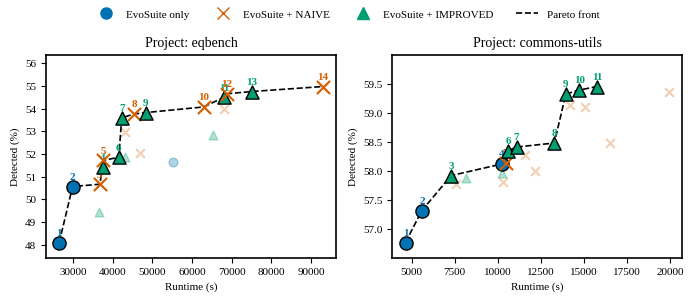

Generated combined Pareto efficiency plot for 2 projects
Generating separate Pareto tables for projects: ['commons-utils' 'eqbench']
Saved LaTeX table to /app/analysis/output/verify/tables/tab-pareto-commons.tex
Saved table: tab-pareto-commons.tex
Saved LaTeX table to /app/analysis/output/verify/tables/tab-pareto-eqbench.tex
Saved table: tab-pareto-eqbench.tex


In [8]:
# Create Pareto efficiency visualization and tables
if not df_efficiency.empty:
    from teralizer.plotting import get_wong_variant_colors, FIGURE_CONFIG
    from matplotlib.lines import Line2D

    wong_colors = get_wong_variant_colors()

    def extract_prefix_and_budget(name):
        match = re.match(r"(.+)-es-default-(\d+s)", name)
        if match:
            return match.group(1), match.group(2)
        return name, None

    def pareto_front(df_points, x_col, y_col):
        sorted_df = df_points.sort_values(x_col)
        pareto = []
        max_y = -float("inf")
        for _, row in sorted_df.iterrows():
            if row[y_col] > max_y:
                pareto.append(row)
                max_y = row[y_col]
        return pd.DataFrame(pareto)

    # Create a DataFrame with project_prefix and search_budget
    prefix_budget = df_efficiency["project_name"].apply(
        lambda x: pd.Series(extract_prefix_and_budget(x))
    )
    prefix_budget.columns = ["project_prefix", "search_budget"]
    df_temp = pd.concat([df_efficiency.reset_index(drop=True), prefix_budget], axis=1)

    project_prefixes = df_temp["project_prefix"].unique()

    # Ensure EqBench comes first for consistent ordering
    if "eqbench" in project_prefixes and "commons-utils" in project_prefixes:
        project_prefixes = ["eqbench", "commons-utils"]
    else:
        project_prefixes = sorted(project_prefixes)

    # Prepare evosuite_points
    evosuite_points = (
        df_temp.groupby(["project_prefix", "search_budget"]).first().reset_index()
    )

    # Create combined figure using FIGURE_CONFIG
    fig_width = FIGURE_CONFIG["width_scatter"]
    fig_height = FIGURE_CONFIG["comparison_height"]
    fig, axes = plt.subplots(
        nrows=1, ncols=len(project_prefixes), figsize=(fig_width, fig_height)
    )
    if len(project_prefixes) == 1:
        axes = [axes]

    for ax, project in zip(axes, project_prefixes):
        proj_df = df_temp[df_temp["project_prefix"] == project].copy()
        evosuite_df = evosuite_points[
            evosuite_points["project_prefix"] == project
        ].copy()

        # Plot all points (faded)
        ax.scatter(
            evosuite_df["evosuite_runtime"],
            evosuite_df["evosuite_detected"],
            marker="o",
            color=wong_colors["INITIAL"],
            alpha=0.3,
            s=40,
            label="EvoSuite only",
        )
        naive_mask = proj_df["teralizer_variant"].str.startswith("NAIVE")
        ax.scatter(
            proj_df[naive_mask]["total_runtime"],
            proj_df[naive_mask]["teralizer_detected"],
            marker="x",
            color=wong_colors["NAIVE_10_TRIES"],
            alpha=0.3,
            s=40,
            label="EvoSuite + NAIVE",
        )
        improved_mask = proj_df["teralizer_variant"].str.startswith("IMPROVED")
        ax.scatter(
            proj_df[improved_mask]["total_runtime"],
            proj_df[improved_mask]["teralizer_detected"],
            marker="^",
            color=wong_colors["IMPROVED_10_TRIES"],
            alpha=0.3,
            s=40,
            label="EvoSuite + IMPROVED",
        )

        # Prepare all points for Pareto front
        es_points = evosuite_df[
            ["evosuite_runtime", "evosuite_detected", "search_budget"]
        ].copy()
        es_points["type"] = "ES"
        es_points["variant"] = None
        es_points.rename(
            columns={"evosuite_runtime": "runtime", "evosuite_detected": "detected"},
            inplace=True,
        )

        naive_points = proj_df[naive_mask][
            [
                "total_runtime",
                "teralizer_detected",
                "search_budget",
                "teralizer_variant",
            ]
        ].copy()
        naive_points["type"] = "NAIVE"
        naive_points.rename(
            columns={"total_runtime": "runtime", "teralizer_detected": "detected"},
            inplace=True,
        )

        improved_points = proj_df[improved_mask][
            [
                "total_runtime",
                "teralizer_detected",
                "search_budget",
                "teralizer_variant",
            ]
        ].copy()
        improved_points["type"] = "IMPROVED"
        improved_points.rename(
            columns={"total_runtime": "runtime", "teralizer_detected": "detected"},
            inplace=True,
        )

        all_points = pd.concat(
            [es_points, naive_points, improved_points], ignore_index=True, sort=False
        )
        pf = pareto_front(all_points, "runtime", "detected")

        # Axis formatting
        y_data_min = min(all_points["detected"].min(), pf["detected"].min())
        y_data_max = max(all_points["detected"].max(), pf["detected"].max())
        y_range = y_data_max - y_data_min
        margin = 0.2 * y_range if y_range > 0 else 0.5
        y_min = y_data_min - margin / 2
        y_max = y_data_max + margin
        ax.set_ylim(y_min, y_max)

        ax.set_title(f"Project: {project}")
        ax.set_xlabel("Runtime (s)")
        ax.set_ylabel("Detected (%)")
        ax.ticklabel_format(style="plain", axis="x")

        # Draw Pareto front line
        ax.plot(
            pf["runtime"],
            pf["detected"],
            linestyle="--",
            color="black",
            linewidth=1.2,
            zorder=2,
            label="Pareto front",
        )

        # Plot and label Pareto front points
        offset = 0.025 * (y_max - y_min)
        for i, (_, row) in enumerate(pf.iterrows(), start=1):
            # Plotting
            if row["type"] == "ES":
                color = wong_colors["INITIAL"]
                marker = "o"
            elif row["type"] == "NAIVE":
                color = wong_colors["NAIVE_10_TRIES"]
                marker = "x"
            elif row["type"] == "IMPROVED":
                color = wong_colors["IMPROVED_10_TRIES"]
                marker = "^"
            else:
                color = "black"
                marker = "o"

            if marker in ["o", "^"]:
                ax.scatter(
                    row["runtime"],
                    row["detected"],
                    marker=marker,
                    color=color,
                    s=90,
                    edgecolor="black",
                    zorder=3,
                )
            else:
                ax.scatter(
                    row["runtime"],
                    row["detected"],
                    marker=marker,
                    color=color,
                    s=90,
                    zorder=3,
                )

            ax.text(
                row["runtime"],
                row["detected"] + offset,
                str(i),
                fontweight="bold",
                color=color,
                ha="center",
                va="bottom",
            )

    # Create legend handles with full opacity (fix faded icon issue)
    legend_handles = [
        Line2D(
            [],
            [],
            marker="o",
            color=wong_colors["INITIAL"],
            markersize=8,
            linestyle="None",
            alpha=1.0,
            label="EvoSuite only",
        ),
        Line2D(
            [],
            [],
            marker="x",
            color=wong_colors["NAIVE_10_TRIES"],
            markersize=8,
            linestyle="None",
            alpha=1.0,
            label="EvoSuite + NAIVE",
        ),
        Line2D(
            [],
            [],
            marker="^",
            color=wong_colors["IMPROVED_10_TRIES"],
            markersize=8,
            linestyle="None",
            alpha=1.0,
            label="EvoSuite + IMPROVED",
        ),
        Line2D(
            [],
            [],
            linestyle="--",
            color="black",
            linewidth=1.2,
            alpha=1.0,
            label="Pareto front",
        ),
    ]

    legend_labels = [h.get_label() for h in legend_handles]

    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    save_figure(fig, "fig_teralizer_efficiency")
    plt.show()

    print(
        f"Generated combined Pareto efficiency plot for {len(project_prefixes)} projects"
    )

    # Generate separate tables for each project
    unique_projects = df_pareto["project_name"].unique()
    print(f"Generating separate Pareto tables for projects: {unique_projects}")

    for project_name in unique_projects:
        try:
            table_content = generate_pareto_points_table(df_pareto, project_name)

            # Determine output filename based on project name
            if "eqbench" in project_name.lower():
                table_filename = "tab-pareto-eqbench"
            elif "commons" in project_name.lower():
                table_filename = "tab-pareto-commons"
            else:
                # Fallback for unexpected project names
                clean_name = project_name.lower().replace("-", "").replace("_", "")
                table_filename = f"tab-pareto-{clean_name}"

            save_latex_table(table_content, table_filename)
            print(f"Saved table: {table_filename}.tex")

        except Exception as e:
            print(f"Error generating table for {project_name}: {e}")

else:
    print("Skipping Pareto efficiency visualization - no data available")

## EvoSuite Runtime Analysis by Phase

Analysis of EvoSuite runtime breakdown across different execution phases and search budget configurations.

In [9]:
# Get and process EvoSuite runtime data
df_evosuite = get_evosuite_runtime_analysis(conn)
df_evosuite_processed = compute_evosuite_phase_statistics(df_evosuite)

print(f"EvoSuite runtime data shape: {df_evosuite_processed.shape}")
print(f"Unique projects: {df_evosuite_processed['project_name'].nunique()}")
print(f"Search budgets: {sorted(df_evosuite_processed['search_budget'].unique())}")

# Define the runtime columns to analyze
runtime_columns = [
    "total",
    "search",
    "inlining",
    "minimization",
    "coverage_analysis",
    "assertion_generation",
    "junit_check",
    "writing_tests",
    "writing_statistics",
    "done",
    "finished",
]

# Create mean and median dataframes by search budget
mean_df = (
    df_evosuite_processed.groupby("search_budget")[runtime_columns].mean().reset_index()
)
mean_df = mean_df.sort_values("search_budget")

median_df = (
    df_evosuite_processed.groupby("search_budget")[runtime_columns]
    .median()
    .reset_index()
)
median_df = median_df.sort_values("search_budget")

print("\nMean EvoSuite runtimes per class:")
display(mean_df)

print("\nMedian EvoSuite runtimes per class:")
display(median_df)

# Export CSV data
csv_data = generate_evosuite_runtime_csv(df_evosuite_processed)
save_csv_data(csv_data, "evosuite-runtime-analysis")

EvoSuite runtime data shape: (1947, 26)
Unique projects: 6
Search budgets: [np.int64(1), np.int64(10), np.int64(60)]

Mean EvoSuite runtimes per class:


,search_budget,total,search,inlining,minimization,coverage_analysis,assertion_generation,junit_check,writing_tests,writing_statistics,done,finished
0,1,47.962695,4.855647,0.285638,2.604803,0.574659,4.583063,34.846772,0.199177,0.011458,0.000636,0.000841
1,10,54.635110,12.329858,0.363864,2.400276,0.619311,4.906615,33.734889,0.267581,0.011416,0.000676,0.000622
2,60,100.639304,56.005274,0.399513,2.701946,0.614159,4.961122,35.616911,0.327371,0.011701,0.000666,0.000641



Median EvoSuite runtimes per class:


,search_budget,total,search,inlining,minimization,coverage_analysis,assertion_generation,junit_check,writing_tests,writing_statistics,done,finished
0,1,34.642994,2.091,0.026,0.363,0.021,0.935,29.610,0.016,0.010,0.001,0.001
1,10,43.948000,11.064,0.018,0.216,0.017,0.958,31.733,0.023,0.011,0.001,0.001
2,60,93.570000,61.040,0.015,0.203,0.015,0.668,31.661,0.025,0.011,0.001,0.001


PosixPath('/app/analysis/output/verify/data/evosuite-runtime-analysis.csv')

Saved figure to /app/analysis/output/verify/figures/fig_evosuite_runtime_phases.pdf


/tmp/ipykernel_920/4065117977.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.arange(n_budgets) % 10)


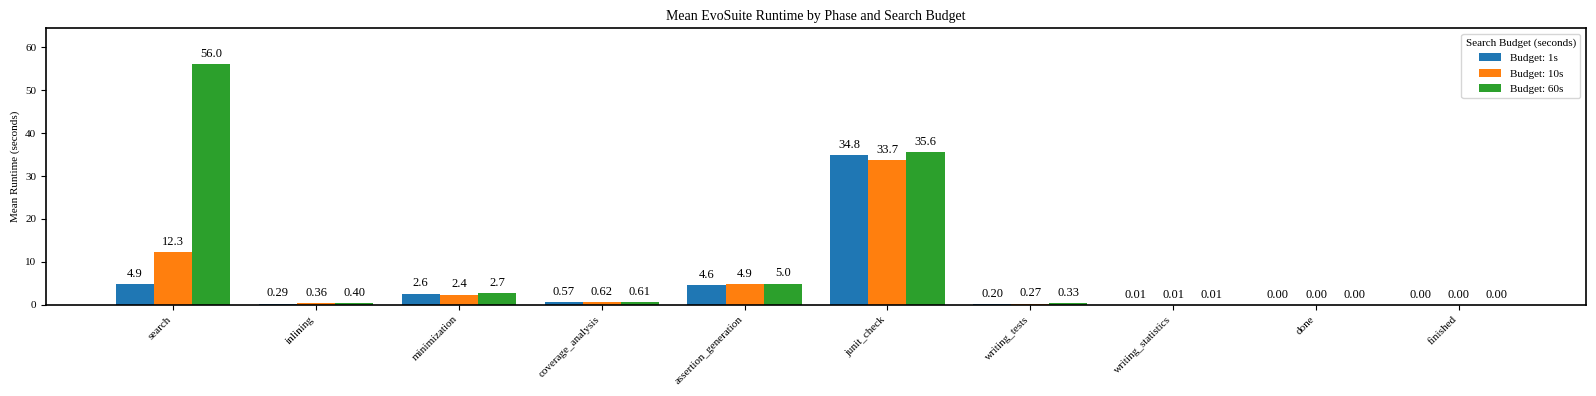

Generated EvoSuite phase analysis for 3 search budgets and 10 phases


In [10]:
# Create EvoSuite phase analysis visualization
if not mean_df.empty:
    # Set search_budget as index
    mean_df_indexed = mean_df.set_index("search_budget")

    # Select only the phase columns (exclude 'total' as it's the sum of all phases)
    phase_columns = [
        "search",
        "inlining",
        "minimization",
        "coverage_analysis",
        "assertion_generation",
        "junit_check",
        "writing_tests",
        "writing_statistics",
        "done",
        "finished",
    ]

    # Transpose to get phases as rows and search budgets as columns
    plot_data = mean_df_indexed[phase_columns].transpose()

    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 4))

    # Get the number of phases and search budgets
    n_phases = len(phase_columns)
    n_budgets = len(plot_data.columns)

    # Set the width of each bar and the spacing between groups
    bar_width = 0.8 / n_budgets
    group_spacing = np.arange(n_phases)

    # Use tab10 colormap
    colors = plt.cm.get_cmap("tab10")(np.arange(n_budgets) % 10)

    # Find the maximum value to adjust y-axis limits
    max_value = plot_data.max().max()

    # Plot each search budget as a set of bars
    for i, (budget, color) in enumerate(zip(plot_data.columns, colors)):
        positions = group_spacing + (i - n_budgets / 2 + 0.5) * bar_width
        bars = ax.bar(
            positions,
            plot_data[budget],
            bar_width,
            label=f"Budget: {budget}s",
            color=color,
        )

        # Add text labels on top of each bar
        for bar_idx, bar in enumerate(bars):
            height = bar.get_height()
            # Format value to 1 decimal place if it's >= 1, otherwise 2 decimal places
            if height >= 1:
                value_text = f"{height:.1f}"
            else:
                value_text = f"{height:.2f}"

            # Position the text above the bar
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                value_text,
                ha="center",
                va="bottom",
                fontsize=9,
            )

    # Set the x-axis labels and positions
    ax.set_xticks(group_spacing)
    ax.set_xticklabels(phase_columns, rotation=45, ha="right")

    # Add labels and title
    ax.set_ylabel("Mean Runtime (seconds)")
    ax.set_title("Mean EvoSuite Runtime by Phase and Search Budget")

    # Add a legend
    ax.legend(title="Search Budget (seconds)")

    # Set y-axis limit to add more space for labels (add 15% padding)
    ax.set_ylim(0, max_value * 1.15)

    # Adjust layout to make room for labels
    plt.tight_layout()
    save_figure(fig, "fig_evosuite_runtime_phases")
    plt.show()

    print(
        f"Generated EvoSuite phase analysis for {n_budgets} search budgets and {n_phases} phases"
    )

else:
    print("No EvoSuite runtime data available for visualization")

## RQ3 Analysis Complete

Generated outputs:
- `tab-teralizer-runtimes.tex` - Total runtime per project
- `teralizer-total-runtimes.csv` - Total runtime data
- `runtime-breakdown-data.csv` - Runtime breakdown by stage and variant data
- `fig_teralizer_runtimes.pdf` - Runtime breakdown by pipeline stage and variant
- `stage-step-runtime-breakdown.csv` - Detailed stage/step runtime breakdown per project
- `stage-step-runtime-statistics.csv` - Aggregated stage/step runtime statistics
- `pareto-efficiency-data.csv` - Pareto efficiency comparison data
- `fig_teralizer_efficiency.pdf` - Pareto efficiency comparison visualization
- `tab-pareto-eqbench.tex` - Pareto optimal points for EqBench project
- `tab-pareto-commons.tex` - Pareto optimal points for Commons-utils project
- `evosuite-runtime-analysis.csv` - EvoSuite runtime phase analysis data
- `fig_evosuite_runtime_phases.pdf` - EvoSuite phase analysis by search budget